In [1]:
from fiatlux.optics.elements.mask import CircularAperture
from fiatlux.core.grid import Grid
from fiatlux.core.spectrum import *
from fiatlux.core.source import *
from fiatlux.optics.propagator import MFTPropagator, IdentityPropagator
from fiatlux.optics.elements.mask import (
    ZeldaMask,
    ZeldaStop,
    ADC,
    TipTilt,
    Piston,
    ArbitraryAperture,
)
from fiatlux.utils.converter import FocalPlaneConverter
from fiatlux.utils.fits_loader import load_pupil, load_zelda_measurement
from fiatlux.optics.elements.field_stop import ShanonFieldStop
from fiatlux.system.optical_system import SerialSystem
from fiatlux.optics.detector import Detector
from fiatlux.optics.elements.deformable_mirror import (
    DeformableMirror,
    ActuatorGrid,
    InteractionMatrix,
    GaussianZonalBasis,
    FourierBasis,
    SquareZonalBasis,
    SquarePTTZonalBasis,
    ZernikeBasis,
)
from fiatlux.optics.adc import ADCDispersionModel

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import json
from config.serial_config import SystemConfig

In [2]:
# %% DEFINITIONS
# Define source spectrum
spectrum = Spectrum(magnitude=5, band=PhotometricBand.HCM, samples=10)

# System parameters
f = 0.125
lambda_max = spectrum.wavelengths.max()
D = 38.542

pupil_mask, (x0, y0, r) = load_pupil("/Users/janinpop/Downloads/outputs/pupil.fits")

# Pupil plane sampling
Nx, Ny = pupil_mask.shape
dx = dy = D / Nx
pupil_grid = Grid(nx=Nx, ny=Ny, dx=dx, dy=dx)

# Focal plane sampling
Nu = Nv = 128
# # Shanon
# du = dv = Nx * (f * l / D) / Nu
du = dv = (50) * (f * lambda_max / D) / (Nu / 2)
focal_grid = Grid(nx=Nu, ny=Nv, dx=du, dy=dv)

# Create source
source = PlaneWave(spectrum=spectrum)

# Empty propagator (for testing)
empty_propagator0 = IdentityPropagator(pupil_grid)
empty_propagator1 = IdentityPropagator(pupil_grid)

# Create aperture
aperture = ArbitraryAperture(grid=pupil_grid, transmission=torch.as_tensor(pupil_mask))

tip_tilt_compensator = TipTilt(grid=pupil_grid, tip=0.0, tilt=0.0)

n_modes = 3
basis = ZernikeBasis(pixel_grid=pupil_grid, n=n_modes)

# DM
dm = DeformableMirror(
    grid=pupil_grid,
    actuator_grid=ActuatorGrid(n_actuators_x=10, n_actuators_y=10, pitch=D / 10),
    pixel_grid=pupil_grid,
    control_basis=basis,
    stroke=lambda_max,
)

# Define propagator
mft0 = MFTPropagator(focal_length=f, output_grid=focal_grid)
mft1 = MFTPropagator(focal_length=f, output_grid=pupil_grid)

theta = torch.as_tensor(lambda_max / 4)
# Define zelda mask
zelda_stop = ZeldaStop(grid=focal_grid, radius=1.06 * f * lambda_max / D)

detector = Detector(
    grid=pupil_grid,
    photon_noise=False,
    readout_noise_variance=0,
    dark_current=0,
    offset=0,
)

system = SerialSystem(
    elements=[
        empty_propagator0,
        aperture,
        tip_tilt_compensator,
        dm,
        mft0,
        zelda_stop,
        mft1,
        empty_propagator1,
    ],
)


def response_function(result):
    detector.acquire(
        (result.field_at(dm) - result.field_at(empty_propagator1))
        + torch.exp(1j * torch.as_tensor(torch.pi) / 2)
        * result.field_at(empty_propagator1)
    )
    return detector.image_buffer


res = system.run(source=source)
reference_image = response_function(res)

/Users/janinpop/Documents/code/fiatlux/.venv/lib/python3.14/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


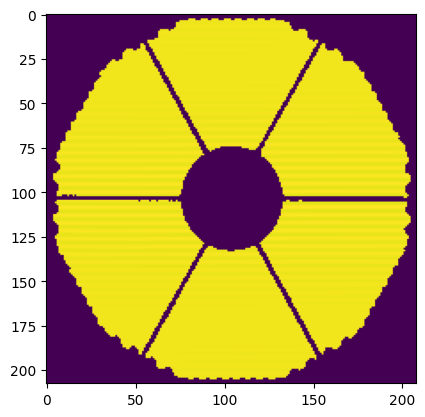

In [3]:
tip_tilt_compensator.tilt = 5e-6
tip_tilt_compensator.build(spectrum=spectrum)
res = system.run(source=source)
image = response_function(res)

tip_tilt_compensator.tilt = 0.0
tip_tilt_compensator.build(spectrum=spectrum)

plt.imshow(image)

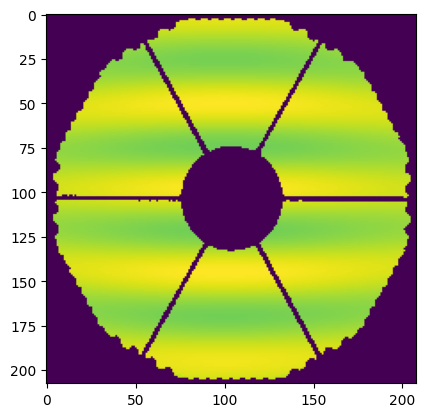

In [6]:
dm._commands = torch.tensor([1.0, 0.0, 0.0])
res = system.run(source=source)
image = response_function(res)


plt.figure()
plt.imshow(image)

ValueError: <matplotlib.colors.PowerNorm object at 0x11c674050> is not a valid value for cmap; supported values are 'Accent', 'Accent_r', 'Blues', 'Blues_r', 'BrBG', 'BrBG_r', 'BuGn', 'BuGn_r', 'BuPu', 'BuPu_r', 'CMRmap', 'CMRmap_r', 'Dark2', 'Dark2_r', 'GnBu', 'GnBu_r', 'Grays', 'Grays_r', 'Greens', 'Greens_r', 'Greys', 'Greys_r', 'OrRd', 'OrRd_r', 'Oranges', 'Oranges_r', 'PRGn', 'PRGn_r', 'Paired', 'Paired_r', 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu', 'PuBuGn', 'PuBuGn_r', 'PuBu_r', 'PuOr', 'PuOr_r', 'PuRd', 'PuRd_r', 'Purples', 'Purples_r', 'RdBu', 'RdBu_r', 'RdGy', 'RdGy_r', 'RdPu', 'RdPu_r', 'RdYlBu', 'RdYlBu_r', 'RdYlGn', 'RdYlGn_r', 'Reds', 'Reds_r', 'Set1', 'Set1_r', 'Set2', 'Set2_r', 'Set3', 'Set3_r', 'Spectral', 'Spectral_r', 'Wistia', 'Wistia_r', 'YlGn', 'YlGnBu', 'YlGnBu_r', 'YlGn_r', 'YlOrBr', 'YlOrBr_r', 'YlOrRd', 'YlOrRd_r', 'afmhot', 'afmhot_r', 'autumn', 'autumn_r', 'berlin', 'berlin_r', 'binary', 'binary_r', 'bone', 'bone_r', 'brg', 'br

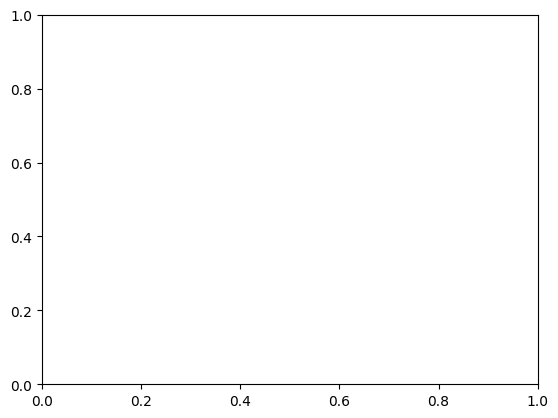

In [45]:
from matplotlib.colors import PowerNorm

pupil_mask, (x0, y0, r) = load_pupil("/Users/janinpop/Downloads/outputs/pupil.fits")
cube = load_zelda_measurement("/Users/janinpop/Downloads/outputs/tip_motor.fits")
for i in range(101):
    plt.imshow(
        (
            cube[i, y0 - r : y0 + r, x0 - r : x0 + r]
            - cube[50, y0 - r : y0 + r, x0 - r : x0 + r]
        )
        * pupil_mask,
        cmap=PowerNorm(0.1),
    )
    plt.draw()
    plt.suptitle(i)
    plt.pause(0.1)

50